In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.head())
print(df.columns)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [3]:
# Choose features (same as regression notebook for consistency)
feature_cols = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]
target_cont = "MedHouseVal"

X = df[feature_cols].values
y_cont = df[target_cont].values

# Create binary label: 1 if MedHouseVal > median, else 0
threshold = np.median(y_cont)
y = (y_cont > threshold).astype(int)

print("Threshold (median house value):", threshold)
print("Label distribution:", np.bincount(y))


Threshold (median house value): 1.797
Label distribution: [10323 10317]


In [4]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (16512, 4) (16512,)
Test shape: (4128, 4) (4128,)


In [5]:
# Normalization

def normalize_features(X):
    mu = np.mean(X, axis=0)
    ptp = np.ptp(X, axis=0)
    X_norm = (X - mu) / ptp
    return X_norm, mu, ptp

def apply_normalization(X, mu, ptp):
    return (X - mu) / ptp

X_train_norm, mu, ptp = normalize_features(X_train)
X_test_norm = apply_normalization(X_test, mu, ptp)

print("Peak to Peak range by column in Raw        X:", np.ptp(X_train, axis=0))
print("Peak to Peak range by column in Normalized X:", np.ptp(X_train_norm, axis=0))


Peak to Peak range by column in Raw        X: [  14.5002      141.06293706 1242.64102564   51.        ]
Peak to Peak range by column in Normalized X: [1. 1. 1. 1.]


In [6]:
# Logistic Regression

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    eps = 1e-8
    cost = -(1/m) * np.sum(y * np.log(f_wb + eps) + (1 - y) * np.log(1 - f_wb + eps))
    return cost

def gradient_logistic(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f_wb = sigmoid(z)
    error = f_wb - y
    dj_dw = (1/m) * (X.T @ error)
    dj_db = (1/m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent_logistic(X, y, w_in, b_in, alpha, num_iters, verbose=True):
    w = w_in.copy()
    b = float(b_in)
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = gradient_logistic(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost_logistic(X, y, w, b)
        J_history.append(cost)

        if verbose and i % max(1, num_iters // 10) == 0:
            print(f"Iteration {i:4d}: Cost {cost:.4f}")

    return w, b, J_history

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict_class(X, w, b, threshold=0.5):
    proba = predict_proba(X, w, b)
    return (proba >= threshold).astype(int)


In [7]:
# Train the Logistic Model

m, n = X_train_norm.shape
w_init = np.zeros(n)
b_init = 0.0
alpha = 0.1
num_iters = 500

w_trained, b_trained, J_history = gradient_descent_logistic(
    X_train_norm, y_train, w_init, b_init, alpha, num_iters, verbose=True
)

print("\nTrained parameters:")
print("w:", w_trained)
print("b:", b_trained)

Iteration    0: Cost 0.6930
Iteration   50: Cost 0.6870
Iteration  100: Cost 0.6812
Iteration  150: Cost 0.6756
Iteration  200: Cost 0.6703
Iteration  250: Cost 0.6652
Iteration  300: Cost 0.6604
Iteration  350: Cost 0.6557
Iteration  400: Cost 0.6512
Iteration  450: Cost 0.6469

Trained parameters:
w: [ 1.54409177  0.03467461 -0.00586544  0.34361187]
b: 0.00039800538060892485


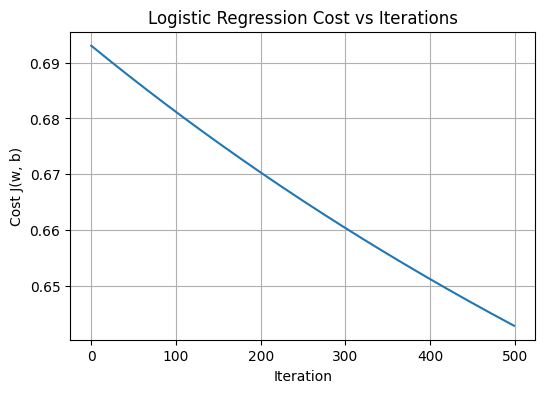

In [8]:
# Plot Cost vs Iterations
plt.figure(figsize=(6,4))
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b)")
plt.title("Logistic Regression Cost vs Iterations")
plt.grid(True)
plt.show()

In [9]:
# Evaluate Accuracy & Threshold Effects

y_train_pred = predict_class(X_train_norm, w_trained, b_trained, threshold=0.5)
y_test_pred  = predict_class(X_test_norm,  w_trained, b_trained, threshold=0.5)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 0.7584
Test  Accuracy: 0.7570


In [10]:
for thr in [0.4, 0.5, 0.6]:
    y_test_thr = predict_class(X_test_norm, w_trained, b_trained, threshold=thr)
    acc_thr = accuracy_score(y_test, y_test_thr)
    print(f"Threshold {thr:.2f} -> Test Accuracy: {acc_thr:.4f}")


Threshold 0.40 -> Test Accuracy: 0.5015
Threshold 0.50 -> Test Accuracy: 0.7570
Threshold 0.60 -> Test Accuracy: 0.5407


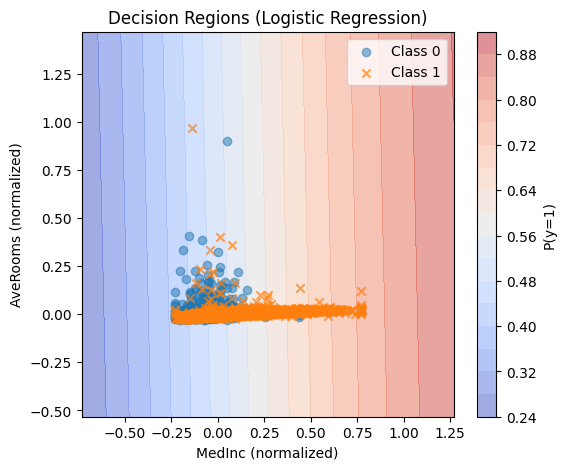

In [11]:
# Visualize Decision Boundary for Two Features (Optional)

feat_idx0 = feature_cols.index("MedInc")
feat_idx1 = feature_cols.index("AveRooms")

X2_train = X_train_norm[:, [feat_idx0, feat_idx1]]
w2 = w_trained[[feat_idx0, feat_idx1]]  # project weights

# Quick re-train only on these two features if you want cleaner boundary:
# w2, b2, _ = gradient_descent_logistic(X2_train, y_train, np.zeros(2), 0.0, 0.1, 500)

b2 = b_trained

# Build grid for plotting
x0_min, x0_max = X2_train[:, 0].min()-0.5, X2_train[:, 0].max()+0.5
x1_min, x1_max = X2_train[:, 1].min()-0.5, X2_train[:, 1].max()+0.5

xx0, xx1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)

grid = np.c_[xx0.ravel(), xx1.ravel()]
proba_grid = predict_proba(grid, w2, b2).reshape(xx0.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx0, xx1, proba_grid, levels=20, alpha=0.5, cmap="coolwarm")
plt.colorbar(label="P(y=1)")
plt.contour(xx0, xx1, proba_grid, levels=[0.5], colors='black')

# Scatter training points
pos = y_train == 1
neg = y_train == 0
plt.scatter(X2_train[neg, 0], X2_train[neg, 1], marker='o', alpha=0.5, label="Class 0")
plt.scatter(X2_train[pos, 0], X2_train[pos, 1], marker='x', alpha=0.7, label="Class 1")

plt.xlabel("MedInc (normalized)")
plt.ylabel("AveRooms (normalized)")
plt.title("Decision Regions (Logistic Regression)")
plt.legend()
plt.show()
